In [18]:
from spyplotter import Spectrum, LineIdentifier, SpectralLine,update_logging_level
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SpectralQuantity, SpectralCoord
%matplotlib widget

In [19]:
import logging
update_logging_level('DEBUG')

# Test Addition of Spectra

## Initialization of a Spectrum

Sometimes, observational spectra are separated in multiple wavelength segments which can also have a different magnitude of error. Mimic a similar behavior to test the addition function by simulating two overlapping spectra with different error:

In [20]:
spectrum_norm = Spectrum.from_powr(filepath='test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=1)

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spec_tools.unit_checks - DEBUG - Use given velocity unit: km / s


In [21]:
yerr1 = np.random.normal(0, 0.005, len(spectrum_norm.x))
mask1 = ((spectrum_norm.x.value >5000) & (spectrum_norm.x.value <6000)) | (((spectrum_norm.x.value >7000) & (spectrum_norm.x.value <8000)))
noisy_spectrum1 = Spectrum(spectrum_norm.x[mask1],(spectrum_norm.y + yerr1)[mask1],yerr=np.abs(yerr1[mask1]))

yerr2 = np.random.normal(0, 0.01, len(spectrum_norm.x))
mask2 = ((spectrum_norm.x.value >5500) & (spectrum_norm.x.value <6200)) | (((spectrum_norm.x.value >6800) & (spectrum_norm.x.value <7500)))
noisy_spectrum2 = Spectrum(spectrum_norm.x[mask2],(spectrum_norm.y + yerr2)[mask2],yerr=np.abs(yerr2[mask2]))

spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spec_tools.unit_checks - DEBUG - Use given velocity unit: km / s
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spec_tools.unit_checks - DEBUG - Use given velocity unit: km / s


spyplotter.spectrum - DEBUG - Using the following pre-specified units:
	x:Angstrom
spyplotter.spectrum - DEBUG - Using the following pre-specified units:
	y:
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - DEBUG - wavelength like units used
spyplotter.spectrum - DEBUG - Using the following pre-specified units:
	x:Angstrom
spyplotter.spectrum - DEBUG - Using the following pre-specified units:
	y:
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - DEBUG - wavelength like units used
spyplotter.spectrum - DEBUG - 2 segments found for self
spyplotter.spectrum - DEBUG - Segments for self:[(5000.0225, 5999.9706), (7000.0328, 7999.9633)]
spyplotter.spectrum - DEBUG - 2 segments found for other
spyplotter.spectrum - DEBUG - Segments for other:[(5500.0235, 6199.9941), (6800.0218, 7499.9532)]
spyplotter.spectrum - DEBUG - 
spyplotter.spectrum - DEBUG - No overlap, so no ave

[0.77819834 0.70646447 0.84740871 ... 0.80556724 0.55567246 0.95027133]

[0.22180166 0.29353553 0.15259129 ... 0.19443276 0.44432754 0.04972867]


[0.38305037 0.29905219 0.23656051 ... 0.4489394  0.3815124  0.15594242]

[0.61694963 0.70094781 0.76343949 ... 0.5510606  0.6184876  0.84405758]


[0.77819834 0.70646447 0.84740871 ... 0.80556724 0.55567246 0.95027133]

[0.22180166 0.29353553 0.15259129 ... 0.19443276 0.44432754 0.04972867]


[0.38305037 0.29905219 0.23656051 ... 0.4489394  0.3815124  0.15594242]

[0.61694963 0.70094781 0.76343949 ... 0.5510606  0.6184876  0.84405758]




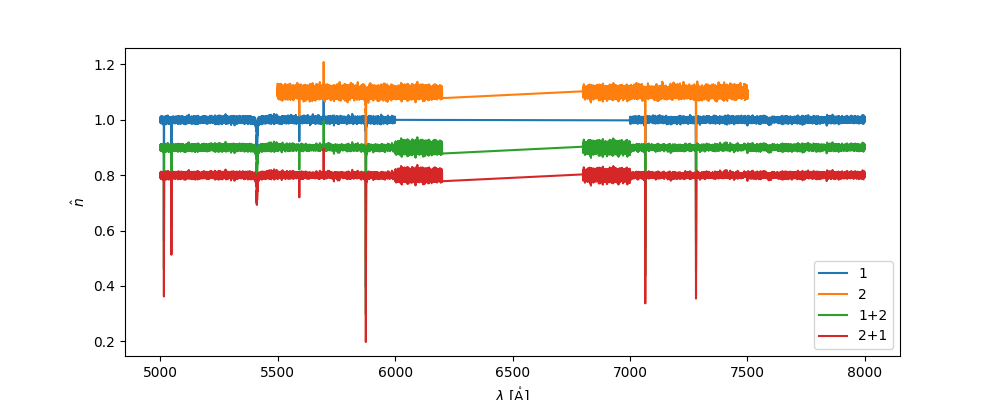

In [23]:
ax = noisy_spectrum1.plot(label='1')
noisy_spectrum2.plot(ax=ax,yshift=0.1,label='2')
new_sp = noisy_spectrum1 + noisy_spectrum2
new_sp = noisy_spectrum2 + noisy_spectrum1
new_sp.plot(ax=ax,yshift=-0.1,label='1+2')
new_sp.plot(ax=ax,yshift=-0.2,label='2+1')
ax.legend()